<a href="https://colab.research.google.com/github/nastya-kolle/mathematical-computational-modeling/blob/main/MCM_04.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Лабораторная работа №4. Модель Лотки-Вольтерры «хищник-жертва»

**Задача.** Промоделировать классическую систему «хищник-жертва»
(модель Лотки-Вольтерры) и её модификацию с логистической поправкой:

`x' = (a - b*y)*x`, `y' = (-c + p*x)*y` — классическая модель;

`x' = (a - b*y)*x + τ*x²`, `y' = (-c + p*x)*y + τ*y²` — модель с логистической поправкой.

Нужно найти точку равновесия, решить систему численно (`solve_ivp`, RK45) для двух наборов
начальных условий и сравнить фазовые траектории классической и модифицированной моделей.


In [ ]:
import pandas
import numpy
import scipy
import sympy
import math
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

In [ ]:
a = 0.51 # коэффициент рождаемости жертв
b = 0.06 # коэффициент поедания жертв
c = 0.37 # коэффициент убыли хищников
p = 0.02 # коэффициент воспроизводства хищников
tau = 0.00035 # логистическая поправка

# Начальные условия
Initial_Condition_1 = [176, 7]  # Жертвы, Хищники
Initial_Condition_2 = [70, 12]   # Жертвы, Хищники

In [ ]:
# Точка равновесия
x_0 = c / p
y_0 = a / b
print(f"Точка равновесия: x* = {x_0:.2f}, y* = {y_0:.2f}")

Точка равновесия: x* = 18.50, y* = 8.50


In [ ]:
# Временной интервал
t = (0, 100)
T = numpy.linspace(t[0], t[1], 1000)

## Задание 1

In [ ]:
def lotka_volterra(t, z):
  x, y = z
  dxdt = (a - b * y) * x
  dydt = (- c + p * x) * y
  return [dxdt, dydt]

solution_1_IC_1 = solve_ivp(lotka_volterra, t, Initial_Condition_1, t_eval=T, method="RK45")
solution_1_IC_2 = solve_ivp(lotka_volterra, t, Initial_Condition_2, t_eval=T, method="RK45")

In [ ]:
def lotka_volterra_logistic(t, z):
  x, y = z
  dxdt = (a - b * y) * x + tau * x ** 2
  dydt = (- c + p * x) * y + tau * y ** 2
  return [dxdt, dydt]

solution_2_IC_1 = solve_ivp(lotka_volterra_logistic, t, Initial_Condition_1, t_eval=T, method='RK45')
solution_2_IC_2 = solve_ivp(lotka_volterra_logistic, t, Initial_Condition_2, t_eval=T, method='RK45')

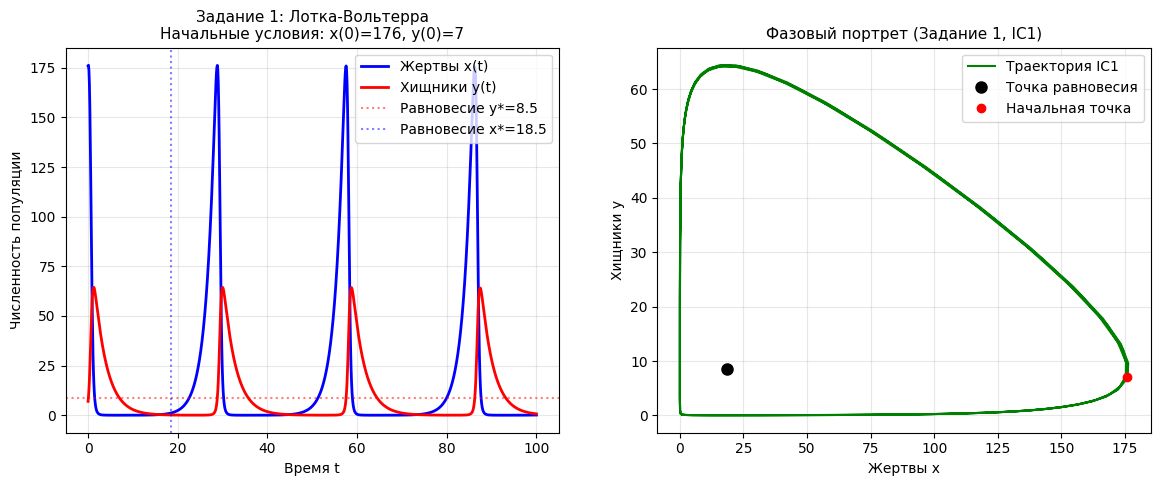

In [ ]:
# --- График 1: Задание 1, начальные условия 1 ---
plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
plt.plot(solution_1_IC_1.t, solution_1_IC_1.y[0], 'b-', label='Жертвы x(t)', linewidth=2)
plt.plot(solution_1_IC_1.t, solution_1_IC_1.y[1], 'r-', label='Хищники y(t)', linewidth=2)
plt.axhline(y=y_0, color='r', linestyle=':', alpha=0.5, label=f'Равновесие y*={y_0:.1f}')
plt.axvline(x=x_0, color='b', linestyle=':', alpha=0.5, label=f'Равновесие x*={x_0:.1f}')
plt.title('Задание 1: Лотка-Вольтерра\nНачальные условия: x(0)=176, y(0)=7', fontsize=11)
plt.xlabel('Время t')
plt.ylabel('Численность популяции')
plt.legend()
plt.grid(True, alpha=0.3)

# Фазовый портрет
plt.subplot(1, 2, 2)
plt.plot(solution_1_IC_1.y[0], solution_1_IC_1.y[1], 'g-', label='Траектория IC1', linewidth=1.5)
plt.plot(x_0, y_0, 'ko', label='Точка равновесия', markersize=8)
plt.plot(Initial_Condition_1[0], Initial_Condition_1[1], 'ro', label='Начальная точка', markersize=6)
plt.title('Фазовый портрет (Задание 1, IC1)', fontsize=11)
plt.xlabel('Жертвы x')
plt.ylabel('Хищники y')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

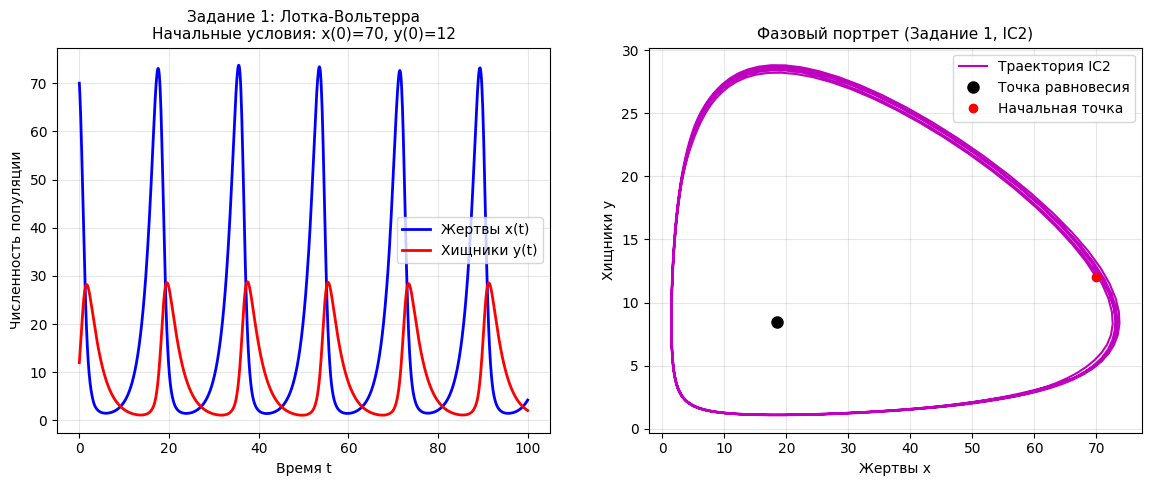

In [ ]:
# --- График 2: Задание 1, начальные условия 2 ---
plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
plt.plot(solution_1_IC_2.t, solution_1_IC_2.y[0], 'b-', label='Жертвы x(t)', linewidth=2)
plt.plot(solution_1_IC_2.t, solution_1_IC_2.y[1], 'r-', label='Хищники y(t)', linewidth=2)
plt.title('Задание 1: Лотка-Вольтерра\nНачальные условия: x(0)=70, y(0)=12', fontsize=11)
plt.xlabel('Время t')
plt.ylabel('Численность популяции')
plt.legend()
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
plt.plot(solution_1_IC_2.y[0], solution_1_IC_2.y[1], 'm-', label='Траектория IC2', linewidth=1.5)
plt.plot(x_0, y_0, 'ko', label='Точка равновесия', markersize=8)
plt.plot(Initial_Condition_2[0], Initial_Condition_2[1], 'ro', label='Начальная точка', markersize=6)
plt.title('Фазовый портрет (Задание 1, IC2)', fontsize=11)
plt.xlabel('Жертвы x')
plt.ylabel('Хищники y')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

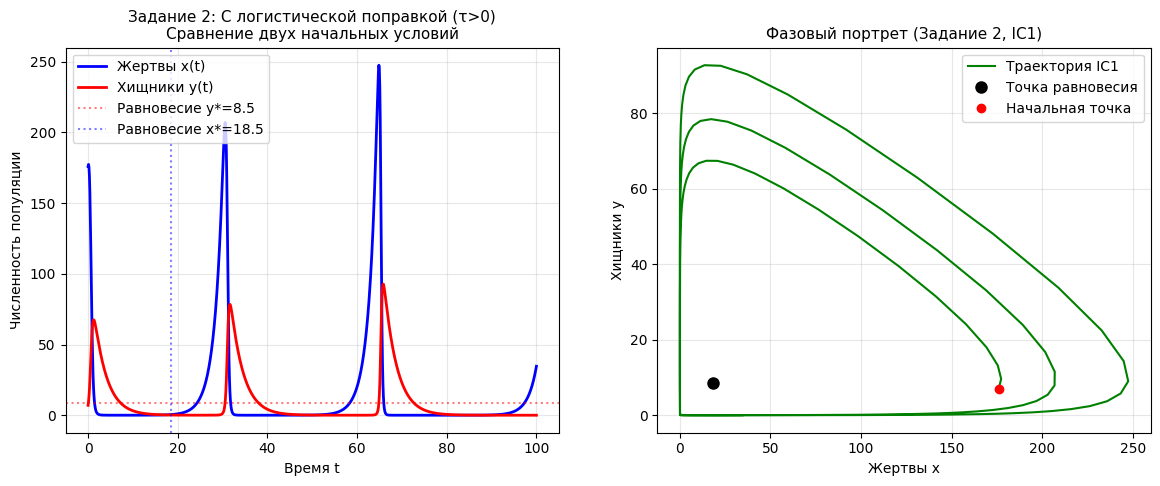

In [ ]:
# --- График 3: Задание 2, начальные условия 1 ---
plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
plt.plot(solution_2_IC_1.t, solution_2_IC_1.y[0], 'b-', label='Жертвы x(t)', linewidth=2)
plt.plot(solution_2_IC_1.t, solution_2_IC_1.y[1], 'r-', label='Хищники y(t)', linewidth=2)
plt.axhline(y=y_0, color='r', linestyle=':', alpha=0.5, label=f'Равновесие y*={y_0:.1f}')
plt.axvline(x=x_0, color='b', linestyle=':', alpha=0.5, label=f'Равновесие x*={x_0:.1f}')
plt.title('Задание 2: С логистической поправкой (τ>0)\nСравнение двух начальных условий', fontsize=11)
plt.xlabel('Время t')
plt.ylabel('Численность популяции')
plt.legend()
plt.grid(True, alpha=0.3)

# Фазовый портрет
plt.subplot(1, 2, 2)
plt.plot(solution_2_IC_1.y[0], solution_2_IC_1.y[1], 'g-', label='Траектория IC1', linewidth=1.5)
plt.plot(x_0, y_0, 'ko', label='Точка равновесия', markersize=8)
plt.plot(Initial_Condition_1[0], Initial_Condition_1[1], 'ro', label='Начальная точка', markersize=6)
plt.title('Фазовый портрет (Задание 2, IC1)', fontsize=11)
plt.xlabel('Жертвы x')
plt.ylabel('Хищники y')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

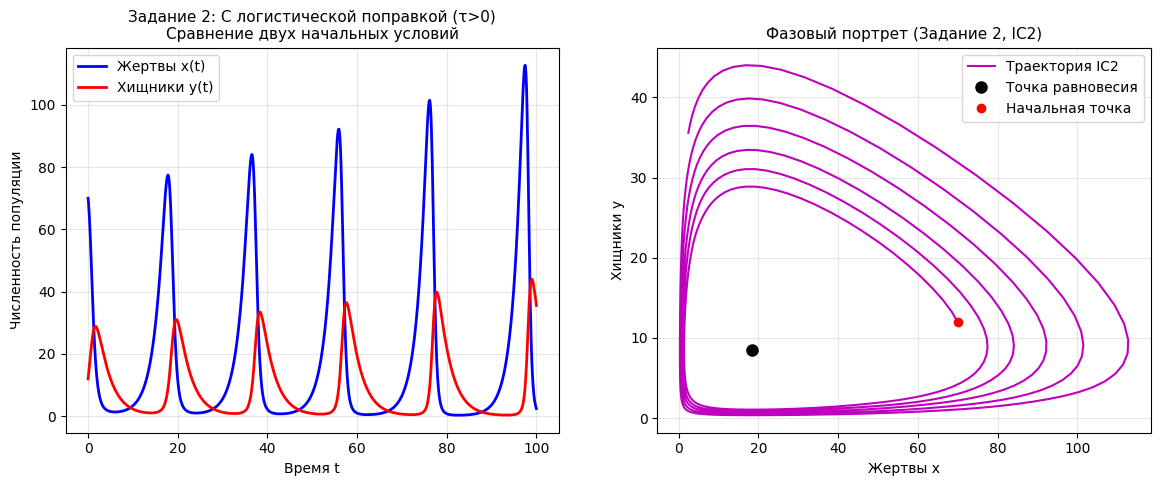

In [ ]:
# --- График 4: Задание 2, начальные условия 2 ---
plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
plt.plot(solution_2_IC_2.t, solution_2_IC_2.y[0], 'b-', label='Жертвы x(t)', linewidth=2)
plt.plot(solution_2_IC_2.t, solution_2_IC_2.y[1], 'r-', label='Хищники y(t)', linewidth=2)
plt.title('Задание 2: С логистической поправкой (τ>0)\nСравнение двух начальных условий', fontsize=11)
plt.xlabel('Время t')
plt.ylabel('Численность популяции')
plt.legend()
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
plt.plot(solution_2_IC_2.y[0], solution_2_IC_2.y[1], 'm-', label='Траектория IC2', linewidth=1.5)
plt.plot(x_0, y_0, 'ko', label='Точка равновесия', markersize=8)
plt.plot(Initial_Condition_2[0], Initial_Condition_2[1], 'ro', label='Начальная точка', markersize=6)
plt.title('Фазовый портрет (Задание 2, IC2)', fontsize=11)
plt.xlabel('Жертвы x')
plt.ylabel('Хищники y')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

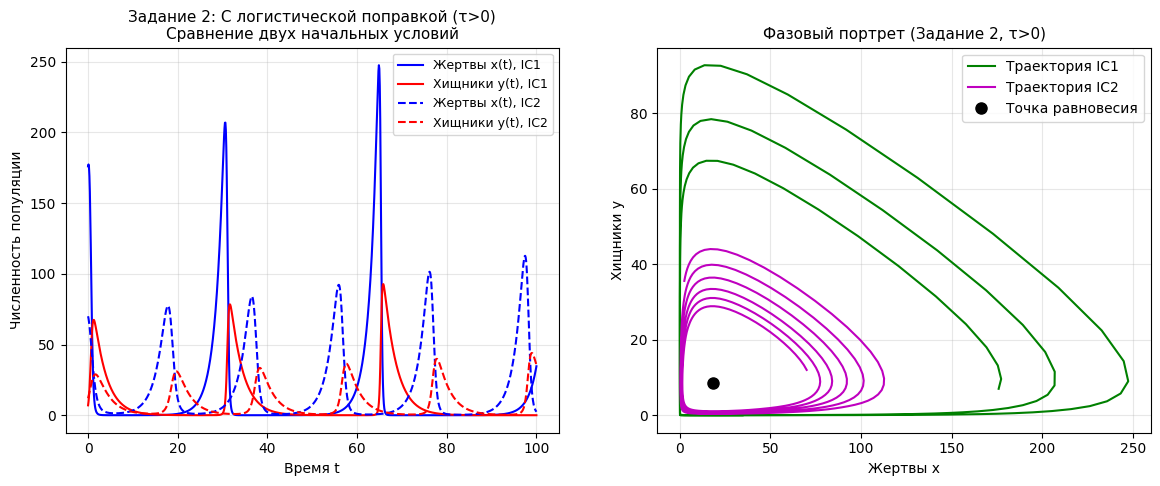

In [ ]:
# --- График 3: Задание 2 (с логистической поправкой), оба начальных условия ---
plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
plt.plot(solution_2_IC_1.t, solution_2_IC_1.y[0], 'b-', label='Жертвы x(t), IC1', linewidth=1.5)
plt.plot(solution_2_IC_1.t, solution_2_IC_1.y[1], 'r-', label='Хищники y(t), IC1', linewidth=1.5)
plt.plot(solution_2_IC_2.t, solution_2_IC_2.y[0], 'b--', label='Жертвы x(t), IC2', linewidth=1.5)
plt.plot(solution_2_IC_2.t, solution_2_IC_2.y[1], 'r--', label='Хищники y(t), IC2', linewidth=1.5)
plt.title('Задание 2: С логистической поправкой (τ>0)\nСравнение двух начальных условий', fontsize=11)
plt.xlabel('Время t')
plt.ylabel('Численность популяции')
plt.legend(fontsize=9)
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
plt.plot(solution_2_IC_1.y[0], solution_2_IC_1.y[1], 'g-', label='Траектория IC1', linewidth=1.5)
plt.plot(solution_2_IC_2.y[0], solution_2_IC_2.y[1], 'm-', label='Траектория IC2', linewidth=1.5)
plt.plot(x_0, y_0, 'ko', label='Точка равновесия', markersize=8)
plt.title('Фазовый портрет (Задание 2, τ>0)', fontsize=11)
plt.xlabel('Жертвы x')
plt.ylabel('Хищники y')
plt.legend()
plt.grid(True, alpha=0.3)